In [167]:
import matplotlib
import pickle
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb
from scipy import stats
from scipy.stats import binom
import datetime
import statistics
import multiprocess as mp
import time
import arviz as az

from epydemix import EpiModel
from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles, plot_trajectories, plot_posterior_distribution_2d
from epydemix.population import load_epydemix_population, Population, get_available_locations
from epydemix.visualization import plot_contact_matrix, plot_population
from epydemix.utils import compute_simulation_dates
from epydemix import simulate
from epydemix.calibration import ABCSampler, rmse
import matplotlib.pyplot as plt
import pandas as pd
from epydemix.visualization import plot_posterior_distribution

from Epy_functions import stochastic_sir
from Epy_functions import stochastic_sir_noisy

In [101]:
model = stochastic_sir(0.3, 0.1, 10000, 10, 100)

In [102]:
incidence_observed = (model['incidence'])

In [103]:
incidence_df = pd.DataFrame(incidence_observed)
incidence_df = incidence_df.rename(columns={0: 'data'})
incidence_df['date'] = pd.date_range(start = '2024/01/01', periods = len(incidence_df), freq='D')
print(incidence_df)

    data       date
0      0 2024-01-01
1      2 2024-01-02
2      4 2024-01-03
3      5 2024-01-04
4      3 2024-01-05
..   ...        ...
95     3 2024-04-05
96     0 2024-04-06
97     0 2024-04-07
98     1 2024-04-08
99     0 2024-04-09

[100 rows x 2 columns]


# Full information parameter recovery

In [ ]:
# Priors
priors = {"beta": stats.uniform(0, .5), 
          "gamma": stats.uniform(0.0, 0.5)}

# Simulation parameters
N = 10000
parameters = {'N': N,
              'n_i': 10,
              'timesteps': 100}

# Wrapper function
def simulate_wrapper(parameters):
    results = stochastic_sir(**parameters)
    return{'data': results['incidence']}

# Initialize the ABCSampler object
abc_sampler = ABCSampler(simulation_function=simulate_wrapper,
                         priors = priors,
                         parameters=parameters,
                         observed_data=incidence_observed,
                         distance_function = rmse)

In [127]:
def smc_calibrate(seed):
    np.random.seed(seed)
    results_smc = abc_sampler.calibrate(strategy='smc',
                                    num_particles=500,
                                    num_generations=10,
                                    )
    return results_smc

In [137]:
start = time.time()
with mp.Pool() as pool:
    pool_smc = pool.map(smc_calibrate, [1,2,3,4])
end = time.time()
print(f"Time taken: {end - start:.2f} seconds")

Starting ABC-SMC with 500 particles and 10 generationsStarting ABC-SMC with 500 particles and 10 generationsStarting ABC-SMC with 500 particles and 10 generationsStarting ABC-SMC with 500 particles and 10 generations




Generation 1/10 (epsilon: inf)
Generation 1/10 (epsilon: inf)

Generation 1/10 (epsilon: inf)
Generation 1/10 (epsilon: inf)


	Accepted 500/500 (acceptance rate: 100.00%)
	Accepted 500/500 (acceptance rate: 100.00%)	Elapsed time: 00:00:00

	Accepted 500/500 (acceptance rate: 100.00%)	Elapsed time: 00:00:00
Generation 2/10 (epsilon: 162.505354)


	Elapsed time: 00:00:00
Generation 2/10 (epsilon: 162.511477)

	Accepted 500/500 (acceptance rate: 100.00%)
Generation 2/10 (epsilon: 162.467535)

	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 162.513261)
	Accepted 500/1419 (acceptance rate: 35.24%)
	Elapsed time: 00:00:00

Generation 3/10 (epsilon: 152.181476)
	Accepted 500/1410 (acceptance rate: 35.46%)
	Elapsed time: 00:00:00
	Accepted 500/1459 (acceptance rate: 34.27%

In [144]:
print(pool_smc[3])

CalibrationResults(calibration_strategy='smc', posterior_distributions={0:          beta     gamma
0    0.197220  0.005949
1    0.009555  0.264875
2    0.464045  0.204374
3    0.296321  0.141075
4    0.183469  0.048997
..        ...       ...
495  0.297133  0.449640
496  0.419694  0.162078
497  0.015162  0.046436
498  0.239648  0.309594
499  0.233392  0.420332

[500 rows x 2 columns], 1:          beta     gamma
0    0.378281  0.410039
1    0.303361  0.325960
2    0.385196  0.386544
3    0.348635  0.323742
4    0.354156  0.100071
..        ...       ...
495  0.217899  0.093582
496  0.356605  0.169114
497  0.425913  0.232074
498  0.424449  0.193680
499  0.478657  0.381019

[500 rows x 2 columns], 2:          beta     gamma
0    0.367570  0.113099
1    0.325633  0.163870
2    0.379336  0.339585
3    0.419377  0.348223
4    0.488007  0.305338
..        ...       ...
495  0.369973  0.307903
496  0.322260  0.087806
497  0.402028  0.413600
498  0.295676  0.130460
499  0.235611  0.024845

[500

In [105]:
results_smc = abc_sampler.calibrate(strategy='smc',
                                    num_particles=500,
                                    num_generations=10,
                                    )

Starting ABC-SMC with 500 particles and 10 generations

Generation 1/10 (epsilon: inf)
	Accepted 500/500 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 162.375229)
	Accepted 500/1513 (acceptance rate: 33.05%)
	Elapsed time: 00:00:00

Generation 3/10 (epsilon: 135.494354)
	Accepted 500/2978 (acceptance rate: 16.79%)
	Elapsed time: 00:00:00

Generation 4/10 (epsilon: 85.092504)
	Accepted 500/5184 (acceptance rate: 9.65%)
	Elapsed time: 00:00:00

Generation 5/10 (epsilon: 60.628333)
	Accepted 500/8767 (acceptance rate: 5.70%)
	Elapsed time: 00:00:01

Generation 6/10 (epsilon: 40.913006)
	Accepted 500/14428 (acceptance rate: 3.47%)
	Elapsed time: 00:00:01

Generation 7/10 (epsilon: 30.222246)
	Accepted 500/23609 (acceptance rate: 2.12%)
	Elapsed time: 00:00:01

Generation 8/10 (epsilon: 22.822576)
	Accepted 500/38508 (acceptance rate: 1.30%)
	Elapsed time: 00:00:02

Generation 9/10 (epsilon: 18.368858)
	Accepted 500/57916 (acceptance rate: 0.86%)
	Elapsed tim

In [126]:
print(results_smc)

CalibrationResults(calibration_strategy='smc', posterior_distributions={0:          beta     gamma
0    0.371323  0.491508
1    0.243191  0.363467
2    0.334970  0.206700
3    0.130732  0.115776
4    0.452267  0.272762
..        ...       ...
495  0.063239  0.172692
496  0.212561  0.164715
497  0.404474  0.154701
498  0.281549  0.451749
499  0.080601  0.062434

[500 rows x 2 columns], 1:          beta     gamma
0    0.477964  0.289661
1    0.243336  0.051316
2    0.412275  0.232069
3    0.187189  0.031391
4    0.274647  0.332120
..        ...       ...
495  0.148914  0.156977
496  0.341716  0.333066
497  0.404792  0.310163
498  0.432631  0.271167
499  0.258462  0.043446

[500 rows x 2 columns], 2:          beta     gamma
0    0.408907  0.311110
1    0.198365  0.051287
2    0.470152  0.242623
3    0.389144  0.198463
4    0.439092  0.394925
..        ...       ...
495  0.311385  0.168744
496  0.234552  0.079263
497  0.255312  0.130144
498  0.290489  0.073206
499  0.458492  0.325427

[500

<Axes: >

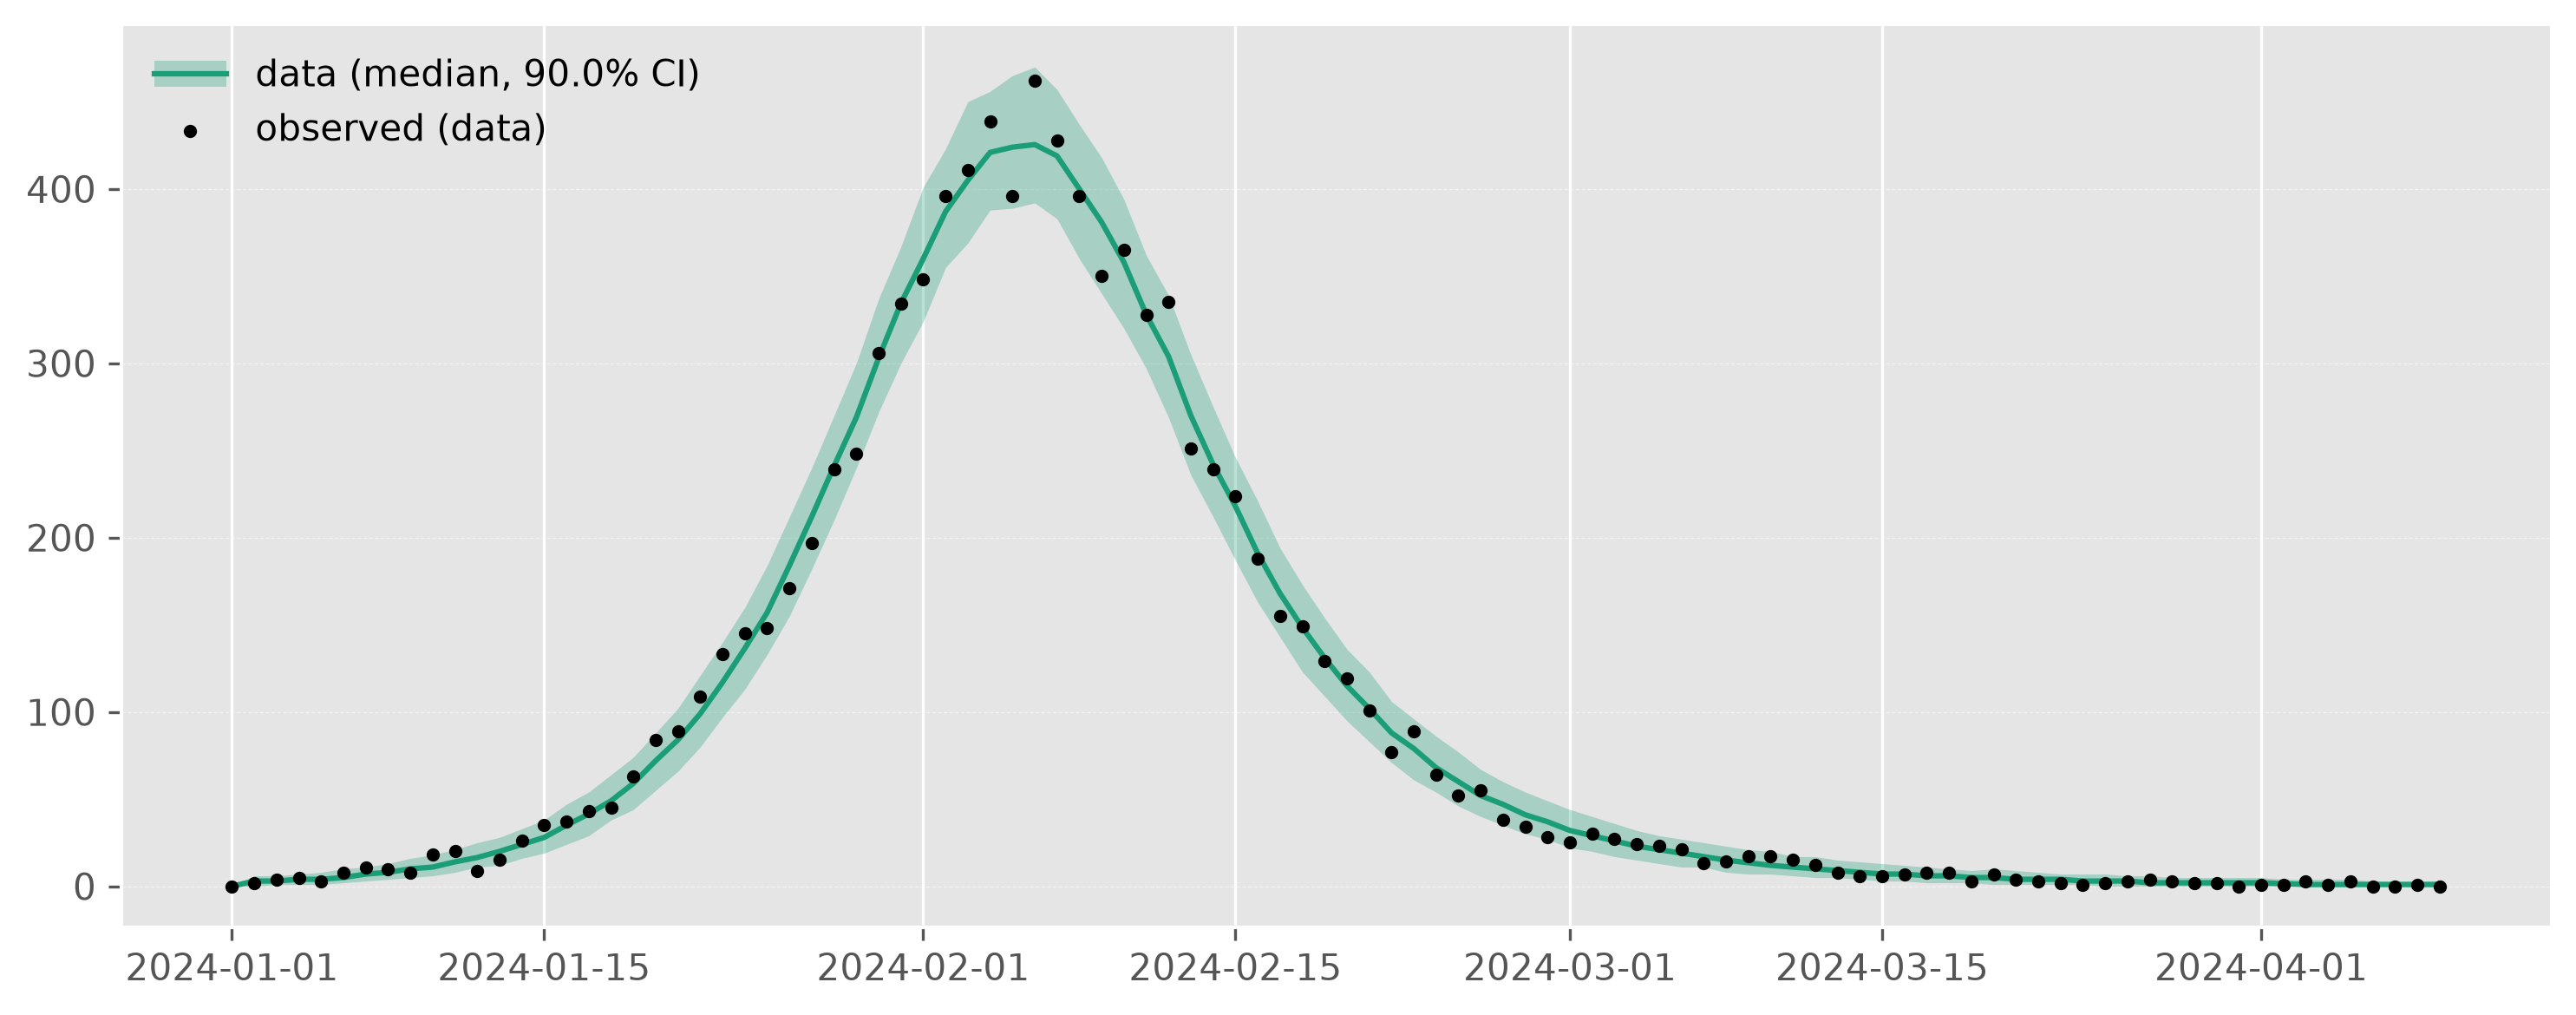

In [150]:
df_quantiles_calibration = pool_smc[1].get_calibration_quantiles(incidence_df['date'])
plot_quantiles(df_quantiles_calibration, columns="data", data=incidence_df, show_legend=True, show_data=True)

In [159]:
df_posterior_0 = pool_smc[0].get_posterior_distribution()
df_posterior_1 = pool_smc[1].get_posterior_distribution()
df_posterior_2 = pool_smc[2].get_posterior_distribution()
df_posterior_3 = pool_smc[3].get_posterior_distribution()

<Axes: title={'center': 'Joint Distribution\nbeta vs gamma'}, xlabel='beta', ylabel='gamma'>

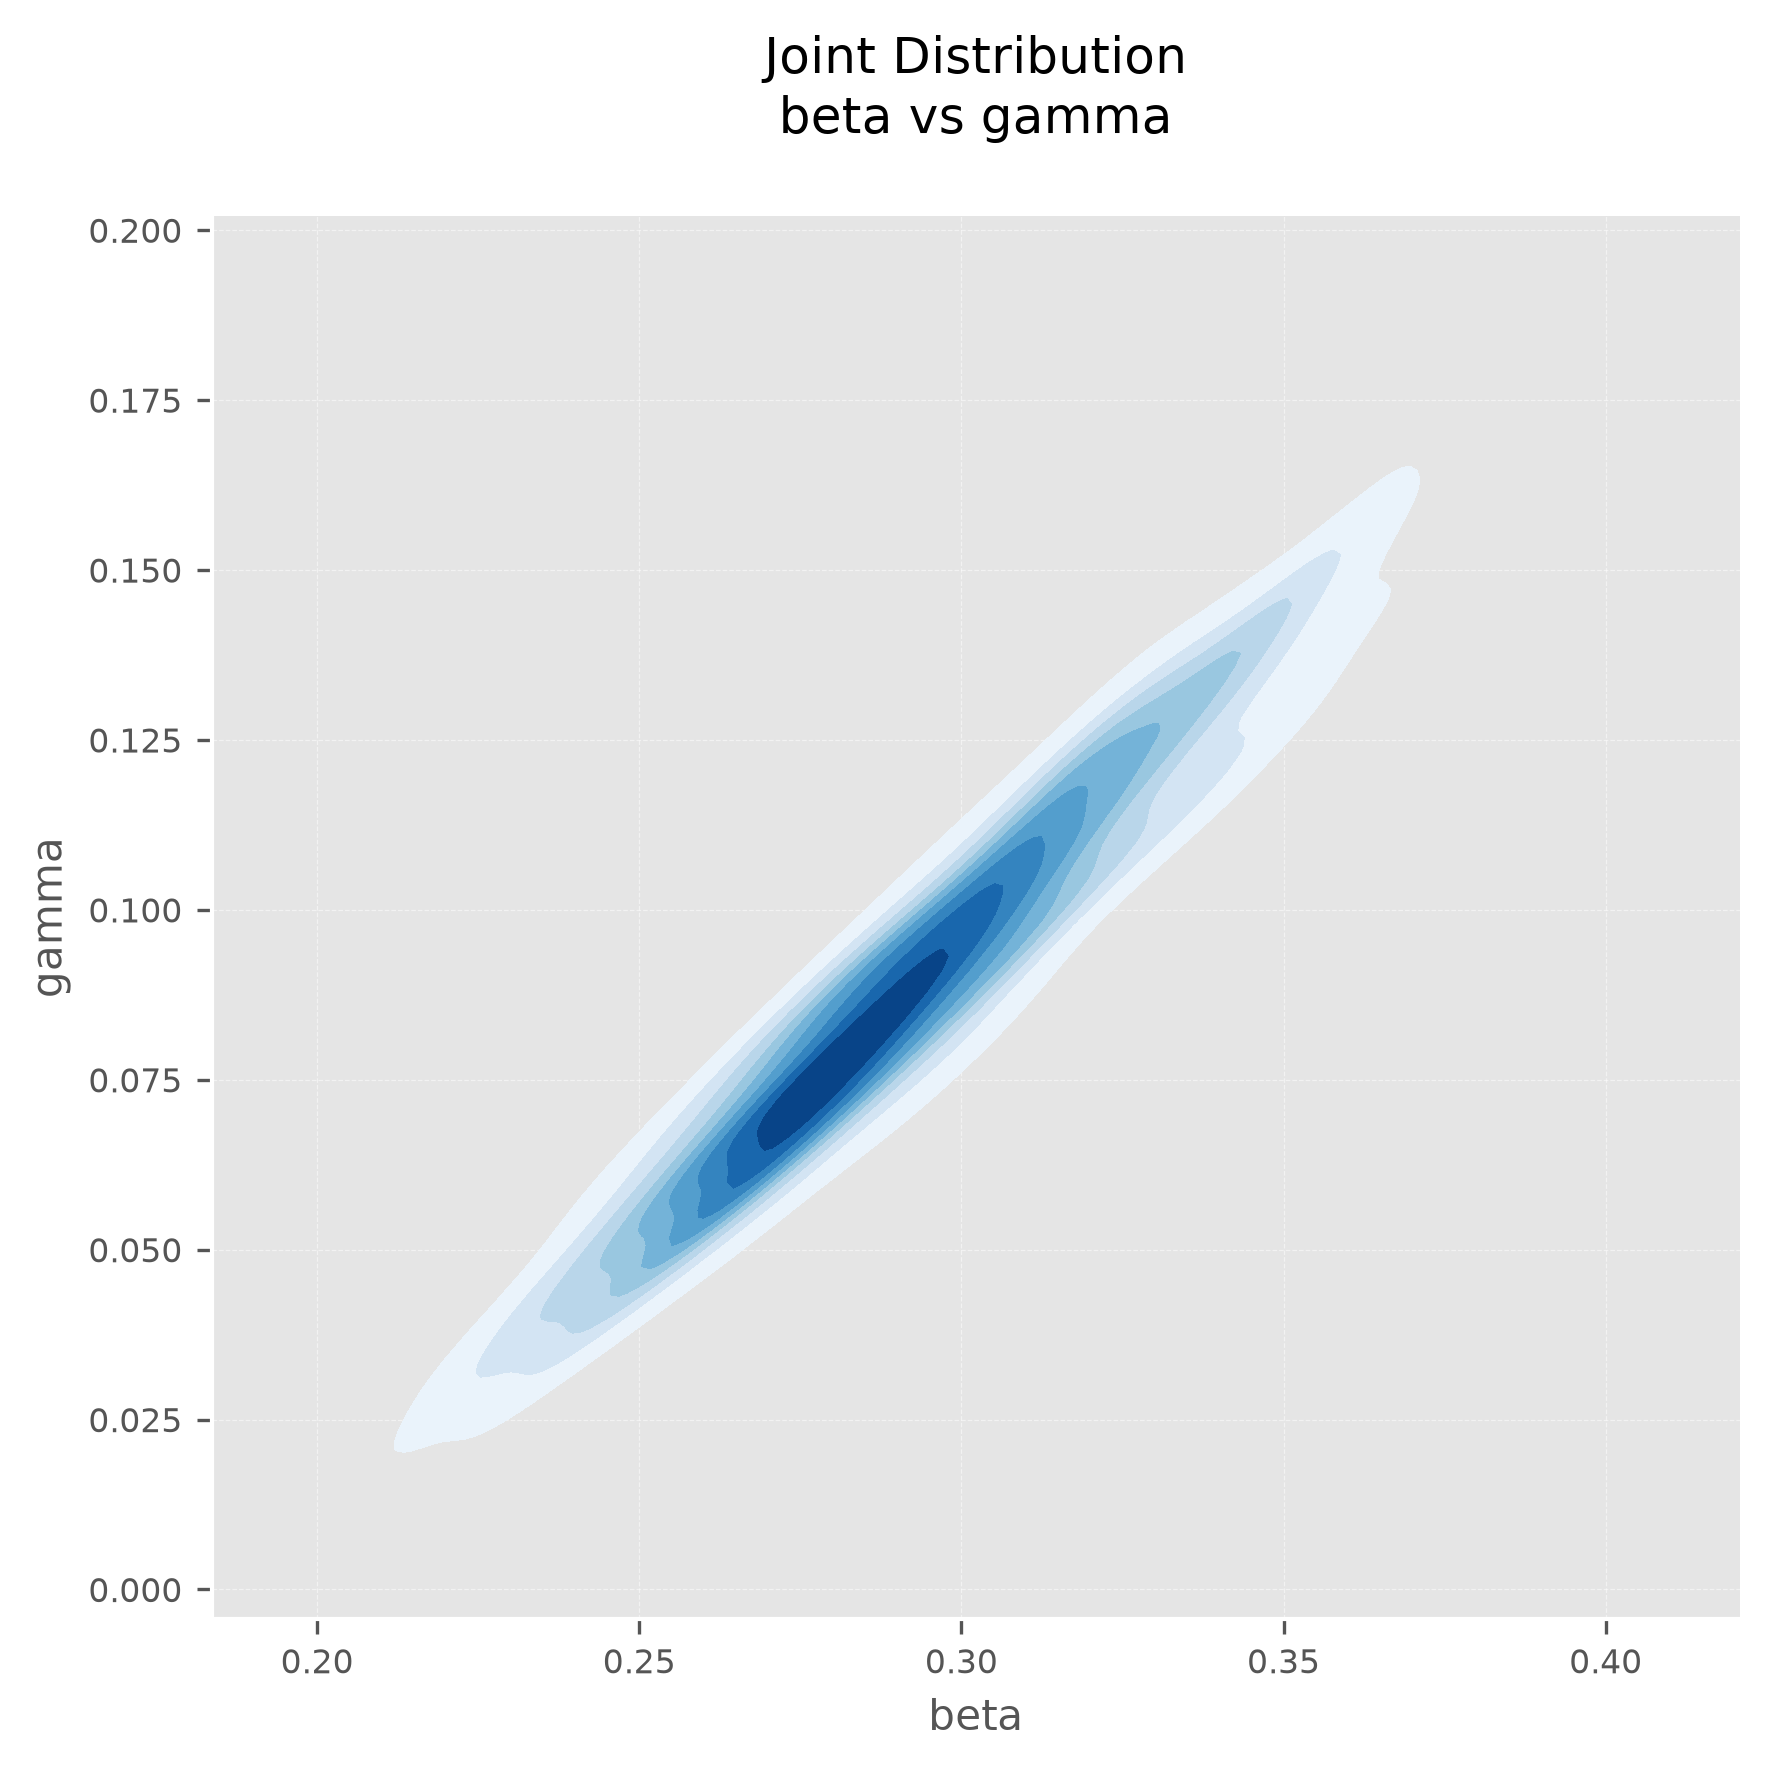

In [160]:
plot_posterior_distribution_2d(df_posterior_0, "beta", "gamma", kind="kde")

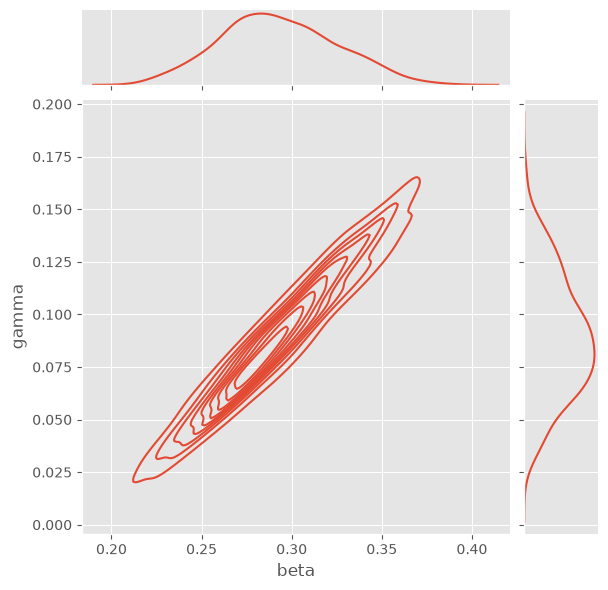

In [161]:
sb.jointplot(x = df_posterior_0['beta'], y = df_posterior_0['gamma'], kind = 'kde')
plt.xlabel('beta')
plt.ylabel('gamma')
plt.show()

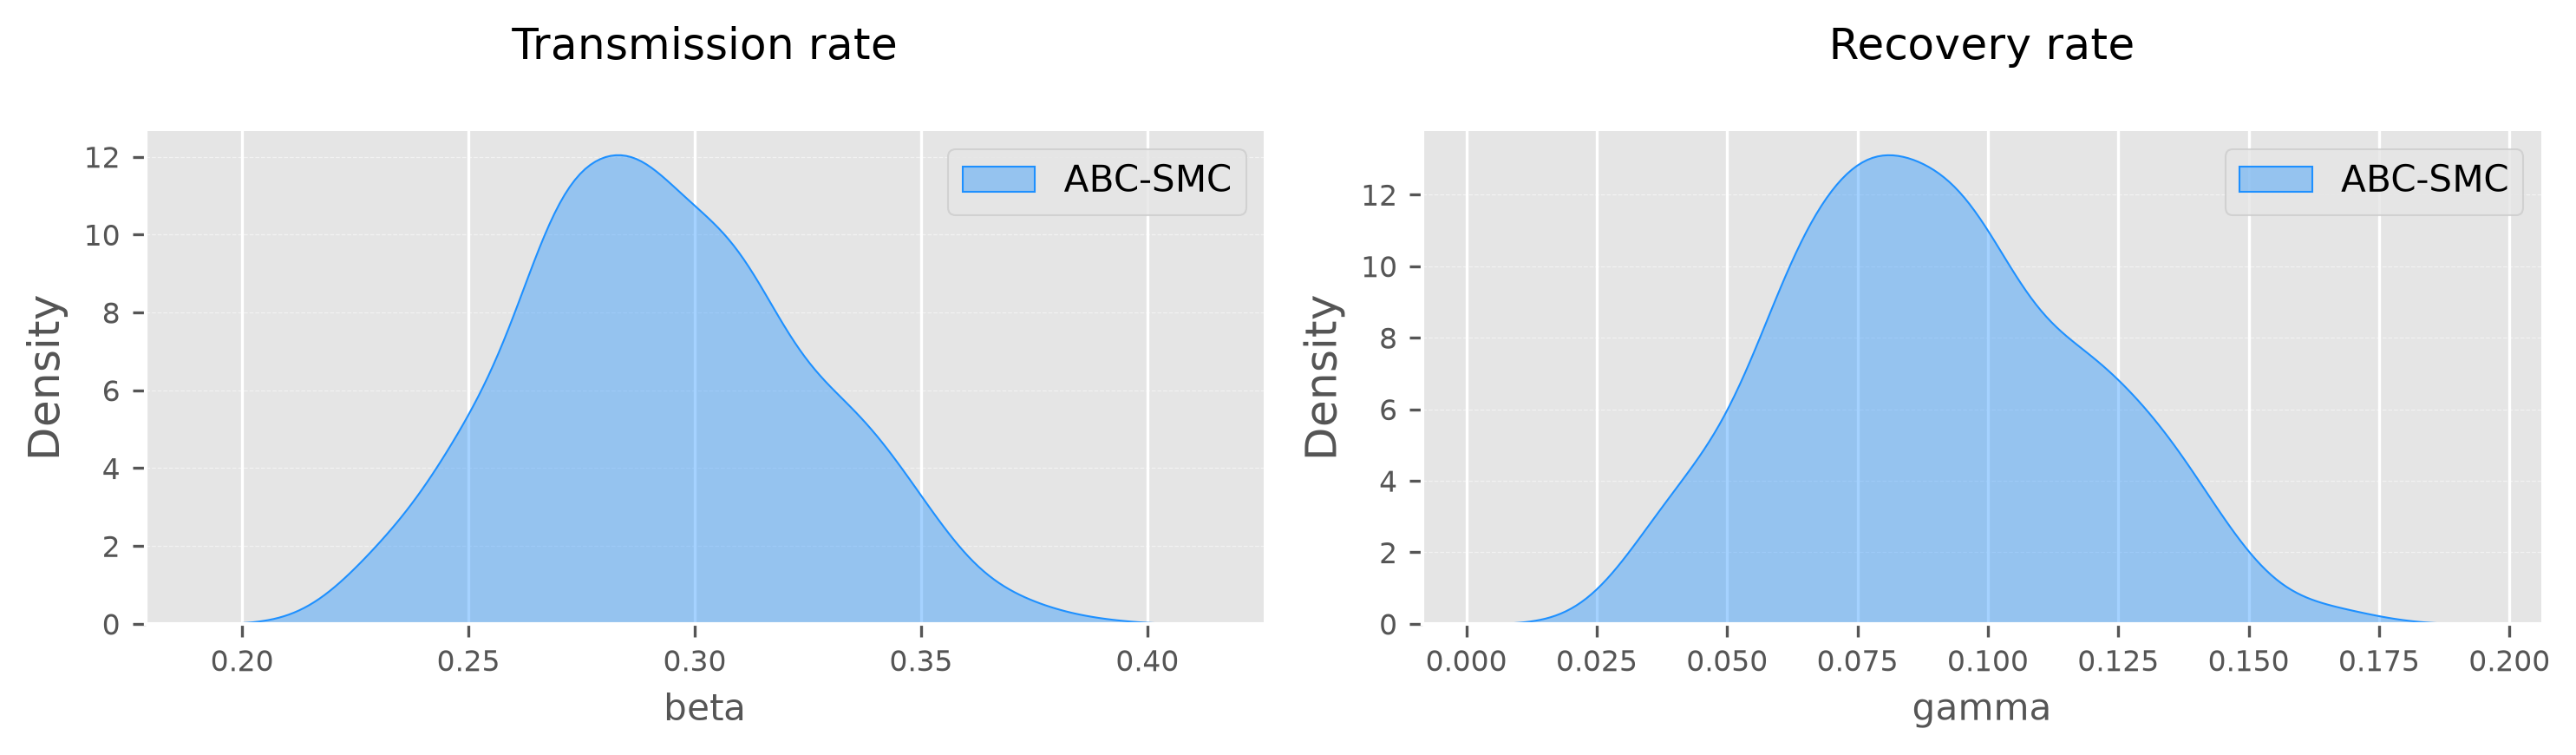

In [162]:


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(pool_smc[0].get_posterior_distribution(), "beta", ax=axes[0], kind="kde", title="Transmission rate", prior_range=False, label="ABC-SMC")
axes[0].legend()    

plot_posterior_distribution(pool_smc[0].get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", title="Recovery rate", prior_range=False, label="ABC-SMC")
axes[1].legend()

In [ ]:
arr_0_beta = (df_posterior_0['beta']).to_numpy()
arr_1_beta = (df_posterior_1['beta']).to_numpy()
arr_2_beta = (df_posterior_2['beta']).to_numpy()
arr_3_beta = (df_posterior_3['beta']).to_numpy()
arr_0_gamma = (df_posterior_0['gamma']).to_numpy()
arr_1_gamma = (df_posterior_1['gamma']).to_numpy()
arr_2_gamma = (df_posterior_2['gamma']).to_numpy()
arr_3_gamma = (df_posterior_3['gamma']).to_numpy()

arr_beta = np.array([arr_0_beta, arr_1_beta, arr_2_beta, arr_3_beta])
arr_gamma = np.array([arr_0_gamma, arr_1_gamma, arr_2_gamma, arr_3_gamma])

In [351]:
print(posterior_beta)

[[0.28026012 0.33842246 0.30381284 0.29232498 0.22935529 0.26301785
  0.29902439 0.3237205  0.28705816 0.2774832  0.34628971 0.27833078
  0.31454317 0.28434286 0.34025573 0.3262693  0.26788428 0.29196399
  0.3265095  0.33189268 0.31183375 0.27317572 0.37465141 0.2965264
  0.33540459 0.28793739 0.31614936 0.30437644 0.2873903  0.27189248
  0.3120236  0.32974388 0.35570429 0.27270898 0.33825141 0.29606556
  0.31230112 0.31760434 0.29054673 0.31698299 0.25023799 0.26430403
  0.24968321 0.28236396 0.25323088 0.30277607 0.31066269 0.27010258
  0.27059123 0.34576631 0.34229676 0.28044374 0.26422654 0.32258151
  0.30069651 0.30755549 0.28850651 0.26853591 0.33779178 0.31465364
  0.35110294 0.30357469 0.29860815 0.30643172 0.2242417  0.28706112
  0.30521267 0.27475755 0.33164119 0.32358253 0.26892528 0.35457484
  0.30679404 0.35191457 0.27961768 0.29591269 0.27035007 0.28626737
  0.2861692  0.25129751 0.27979662 0.25163757 0.30844899 0.27241845
  0.32107777 0.23859191 0.28241989 0.28152573 0.2

In [337]:
summary = {'Parameter': ['Beta', 'Gamma'],
           'Mean': [az.mean(arr_beta, round_to=4), az.mean(arr_gamma, round_to=4)],
           'Variance': [round(statistics.variance(arr_beta.flatten()),4), round(statistics.variance(arr_gamma.flatten()),4)],
           'Std': [az.std(arr_beta, round_to=4), az.std(arr_gamma, round_to=4)],
           'eti95_lb': [round(az.eti(arr_beta.flatten())[0],4), round(az.eti(arr_gamma.flatten())[0],4)],
           'eti95_ub': [round(az.eti(arr_beta.flatten())[1],4), round(az.eti(arr_gamma.flatten())[1],4)],
           'hdi95_lb': [round(az.hdi(arr_beta.flatten())[0],4), round(az.hdi(arr_gamma.flatten())[0],4)],
           'hdi95_ub': [round(az.hdi(arr_beta.flatten())[1],4), round(az.hdi(arr_gamma.flatten())[1],4)],
           'ess_bulk': [round(az.ess(arr_beta, method='bulk').item(),4), round(az.ess(arr_gamma, method='bulk').item(),4)],
           'ess_tail': [round(az.ess(arr_beta, method='tail', prob=0.95).item(),4), round(az.ess(arr_gamma, method='tail', prob=0.95).item(),4)],
           'rhat': [round(az.rhat(arr_beta).item(),4), round(az.rhat(arr_gamma).item(),4)],
           'mcse_mean': [round(az.mcse(arr_beta, method='mean').item(),4), round(az.mcse(arr_gamma, method='mean').item(),4)],
           'mcse_std': [round(az.mcse(arr_beta, method='sd').item(),4), round(az.mcse(arr_gamma, method='sd').item(),4)]
           }

df_summary = pd.DataFrame(summary)

In [335]:
display(df_summary)

,Parameter,Mean,Variance,Std,eti95_lb,eti95_ub,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,rhat,mcse_mean,mcse_std
0,Beta,0.2947,0.0010,0.0314,0.2463,0.3477,0.2446,0.3436,1874.9583,1948.7872,0.9996,0.0007,0.0005
1,Gamma,0.0914,0.0008,0.0278,0.0485,0.1388,0.0499,0.1394,1852.8347,1950.9067,1.0000,0.0006,0.0004
